In [ ]:
import numpy as np
from matplotlib import pyplot as plt

"""
Aw-Rascle-Zhang / Lighthill-Witham-Richards Traffic models

Author: Claire R. A. Curry
Date: April 22, 2026
Course: APMA 935, Simon Fraser University, 2026

Numerical Methods:
- Godunov Finite Volume
- Time discretization: Forward Euler

Problem Description:
- See report write up
"""


In [ ]:

def lwr_traffic_solver(uL, uR):

    Vmax   = 1
    rhoMax = 1

    v = lambda rho: Vmax*(1-rho/rhoMax)
    q = lambda rho: rho*v(rho)
    qp= lambda rho: Vmax*(1-2*rho/rhoMax)
    qpL = qp(uL)
    qpR = qp(uR)
    
    if uR == uL:
        s = 0
    else:
        s = (q(uR) - q(uL))/(uR - uL)


    if uR == uL:
        uStar = uR

    # Rarefaction
    elif qpL <= qpR:
        if     0 <= qpL and qpL <= qpR : uStar = uL
        elif qpL <= 0   and qpR >= 0   : uStar = 1/2
        elif qpL <= qpR and qpR <= 0   : uStar = uR
        else: print("Error(1)")

    # Shock
    elif qp(uL) > qp(uR):
        if   s <=0 : uStar = uR
        elif s >=0 : uStar = uL
        else: print("ERROR(2)")

    else: print("ERROR(3)")

    return q(uStar)

def lwr_traffic_1D_ROE(uL,uR):

    # Entropy fix
    if uL >= 1/2 and 1/2 > uR:
        s = 1 - uL - uR
        flux = uL*(1-uL) + (1 - 2*uL)*(((1 - 2*uR) - s)/(1-2*uR - (1 - 2*uL)))*(uR - uL)
    # Linearized solution
    else:
        A = 1 - uL - uR
        if A > 0:
            flux = uL*(1-uL)
        else:
            flux = uR*(1-uR)

    return flux


In [3]:
# ARZ Flux Solver

# Based on the work of Mammar et al. (2009)

def arz_traffic_1D(uL,uR):

    # Initialization
    Vmax = 1
    rhoMax = 1
    gamma = 1

    Ve = lambda rho: Vmax*(1-(rho/rhoMax)**gamma)
    Vpe = lambda rho: -gamma*(rho/rhoMax)**(gamma-1)/rhoMax

    def Vein(v): # Extended from the fundamental diagram
        if v <= Vmax and v >= 0:
            return (1 - v)**(1/gamma)
        elif v <= 0:
            return rhoMax
        elif v >= Vmax:
            return 0

    Qepin = lambda q: (1 - q)/(gamma+1)**(1/gamma)
    flux = lambda q,v: np.array([q[0]*v , q[1]*v])
   
    uStar = np.zeros(uL.shape)

    # For readability
    vL = uL[1]/uL[0] + Ve(uL[0])
    vR = uR[1]/uR[0] + Ve(uR[0])
   
    rhoL = uL[0]
    rhoR = uR[0]

    v0 = vR
    rho0 = Vein(vR - vL + Ve(rhoL))

    # Genuinely nonlinear eigenvalue
    eig1 = lambda rho, v: v + rho * Vpe(rho)

    # Error Checking
    if any(uR) == np.inf or any(uL == np.inf):
        print("Instability detected")

    if uL[0] > rhoMax or uL[1]/uL[0] + Ve(uL[0]) > Vmax:
        print("Over maximum")
   
    if uR[0] > rhoMax or uR[1]/uR[0] + Ve(uR[0]) > Vmax:
        print("Over maximum")
    

    if uL[0] < 0 or uR[0] < 0: print("Rho negative")
    if uL[1]/uL[0] + Ve(uL[0]) < 0 or uL[1]/uL[0] + Ve(uL[0]) < 0: print("Velocity negative")

    # Case 1
    if vR - vL + Ve(rhoL) > Vmax:

        # Case 1.1
        if eig1(rhoL,vL) <= 0:

            rhoStar = Qepin(-vL + Ve(rhoL))
            vStar = Ve(rhoStar) + vL - Ve(rhoL)

        # Case 1.2
        elif eig1(rhoL,vL) >= 0:

            vStar = vL
            rhoStar = rhoL
    
    # Case 2
    elif 0 <= vR - vL + Ve(rhoL) <= Vmax:

        # Case 2.1
        if vR <= vL:

            # Case 2.1.1
            if rho0*v0 - rhoL*vL <= 0:

                vStar = v0
                rhoStar = rho0

            # Case 2.1.2
            elif rho0*v0 - rhoL*vL >= 0:

                vStar = vL
                rhoStar = rhoL
        
        # Case 2.2
        if vR >= vL:

            # Case 2.2.1
            if vL + rhoL*Vpe(rhoL) >= 0:

                vStar = vL
                rhoStar = rhoL  
            
            # Case 2.2.2
            elif v0 + rho0*Vpe(rho0) <= 0:

                vStar = vR
                rhoStar = rho0

            # Case 2.2.3
            elif vL + rhoL*Vpe(rhoL) <= 0 and v0 + rho0*Vpe(rho0) >= 0:

                rhoStar = Qepin(-vL + Ve(rhoL))
                vStar = Ve(rhoStar) + vL -Ve(rhoL)

    # Case 3
    elif vR <= vL - Ve(rhoL):

        # Case 3.1
        if vR >= (rhoL / rhoMax) *vL:

            vStar = vL
            rhoStar = rhoL

        # Case 3.2
        if vR <= (rhoL / rhoMax) *vL:

            vStar = v0
            rhoStar = rho0

    rStar = rhoStar*(vStar - Ve(rhoStar)) # Change to r conserved quantity
    uStar[0] = rhoStar
    uStar[1] = rStar

    # Calculate flux.

    return flux(uStar,vStar)

In [4]:

# Boundary condition helper functions


# Dirichlet Boundary Conditions
def dirichlet_bc(u,num_ghost_each_end):

    valueL = 0.4
    valueR = 0.5

    for j in range(num_ghost_each_end):
        u[j ] = valueL
        u[-(j+1)] = valueR

    return u

# Red-light-green-light Boundary Conditions
def red_light_green_light_periodic(u, num_ghost_each_end, num_eqn=1, t=0):
    if num_eqn == 1:
        for j in range(num_ghost_each_end):
            if np.floor(2*t) % 2 == 0:
                # Red light: set ghost cells to high density (stopped traffic)
                u[j] = 0
                u[-(j+1)] = 1.0
            else:
                # Green light: periodic BC
                u[j] = u[-num_ghost_each_end-1 + j]
                u[-(j+1)] = u[num_ghost_each_end + j]
    else:
        for j in range(num_ghost_each_end):
            if np.floor(2*t) % 2 == 0:
                u[0, j] = 0.0001
                u[1, j] = 0 #-u[0,j]*(1-u[0,j])
                u[0, -(j+1)] = 1.0
                u[1, -(j+1)] = 0 #-u[0,-(j+1)]*(1-u[0,-(j+1)])
            else:
                u[:, j] = u[:, -num_ghost_each_end-1 + j]
                u[:, -(j+1)] = u[:, num_ghost_each_end + j]
    return u

# Periodic Boundary Conditions
def periodic_bc(u, num_ghost_each_end, num_eqn=1, t=0):
    if num_eqn == 1:
        for j in range(num_ghost_each_end):
            u[j] = u[-num_ghost_each_end-1 + j]
            u[-(j+1)] = u[num_ghost_each_end + j]
            
    else:
        for j in range(num_ghost_each_end):
            u[:, j]      = u[:, -num_ghost_each_end-1 + j]
            u[:, -(j+1)] = u[:, num_ghost_each_end + j]

    return u

# Quadratic Interpolation of Free-Flow Boundary Condition
def interp_bc(u,num_ghost_each_end,num_eqn = 1,t=0):
    if num_eqn == 1:
        for j in range(num_ghost_each_end):
            u[j] = 3*u[num_ghost_each_end] - 3*u[num_ghost_each_end+1] + u[num_ghost_each_end+2]
            u[-1-j] = 3*u[-1-num_ghost_each_end] - 3*u[-2-num_ghost_each_end] + u[-3-num_ghost_each_end]
    else:
        for j in range(num_ghost_each_end):
            u[:,j] = 3*u[:,num_ghost_each_end] - 3*u[:,num_ghost_each_end+1] + u[:,num_ghost_each_end+2]
            u[:,-1-j] = 3*u[:,-1-num_ghost_each_end] - 3*u[:,-2-num_ghost_each_end] + u[:,-3-num_ghost_each_end]
    return u


In [5]:

# Godunov Solver time steps the numerical solution based on the flux solver given as argument
def godunov_solve_1D(a,b,U0,dt,dx,T,solver,bc):

    M = int((b-a)//dx)

    NUM_GHOST_EACH_END = 1
    NUM_CELLS = M + 2 + 2 * NUM_GHOST_EACH_END

    XX = np.linspace(a,b,NUM_CELLS)
    TT = np.arange(0,T,dt)

    UU = np.zeros((int(T//dt)+2,NUM_CELLS))
    UU[0,:] = U0(XX)

    for n,t in enumerate(TT):

        # Handle boundary for this timestep
        UU[n,:] = bc(UU[n,:],NUM_GHOST_EACH_END,1,t)


        for j in range(NUM_GHOST_EACH_END, NUM_CELLS - NUM_GHOST_EACH_END):
            
            # Solver should return the xi = 0 similarity solution for the Riemann problem
            leftFlux  = solver( UU[n,j-1] , UU[n,j  ] )
            rightFlux = solver( UU[n,j  ] , UU[n,j+1] )

            # Godunov Step
            UU[n+1,j] = UU[n,j] - (dt/dx)*( rightFlux - leftFlux )
    

    return UU[:,1:-1],XX[1:-1],TT

# Godunov Solver for systems of hyperbolic conservation laws
def godunov_solve_1D_sys(a,b,U0,dt,dx,T,solver,bc,num_eqn,forcing=None):

    NUM_GHOST_EACH_END = 1

    M = int((b-a)//dx)
    NUM_CELLS = M + 2 + 2 * NUM_GHOST_EACH_END
    
    XX = np.linspace(a,b,NUM_CELLS)
    print(f"dx = {dx} given, effective dx = {XX[NUM_GHOST_EACH_END+1]-XX[NUM_GHOST_EACH_END]}")
    TT = np.arange(0,T,dt)

    UU = np.zeros((num_eqn,int(T//dt)+2,NUM_CELLS))
    UU[:,0,:] = U0(XX)

    for n,t in enumerate(TT):

        # Handle boundary for this timestep
        UU[:,n,:] = bc(UU[:,n,:],NUM_GHOST_EACH_END,num_eqn,t)

        for j in range(NUM_GHOST_EACH_END, NUM_CELLS - NUM_GHOST_EACH_END):
            
            # Solver should return the xi = 0 similarity solution for the Riemann problem
            leftFlux  = solver( UU[:,n,j-1] , UU[:,n,j  ] )
            rightFlux = solver( UU[:,n,j  ] , UU[:,n,j+1] )

            # Godunov Step
            UU[:,n+1,j] = UU[:,n,j] - (dt/dx)*( rightFlux - leftFlux )

            # Forcing Step
            if forcing != None:
                UU[:,n+1,j] = UU[:,n+1,j] + dt*forcing(UU[:,n+1,j]) 

    
    return UU[:,:,1:-1],XX[1:-1],TT

            


dx = 0.001 given, effective dx = 0.000998003992015968


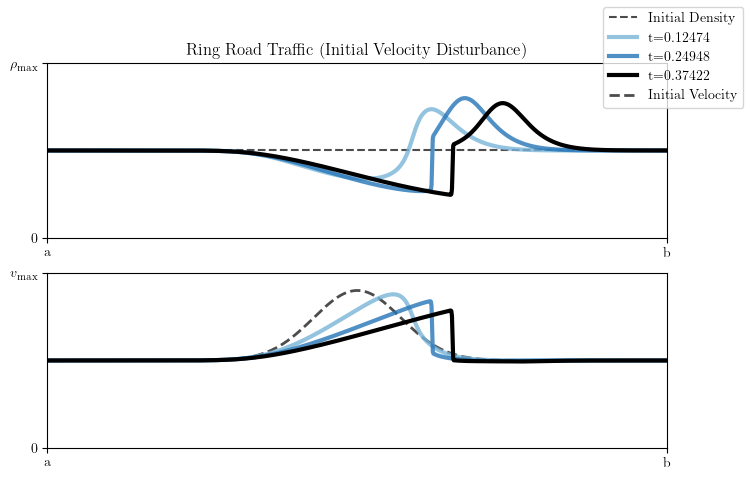

In [26]:
# Ring Road Simulation Code Example

# Initial Conditions
rho0 = lambda x: np.ones(x.shape)*0.5
v0   = lambda x: np.ones(x.shape)*0.5 + 0.4*np.exp(-100*(x-0.5)**2)
y0 = lambda x: rho0(x)*(v0(x)-1+rho0(x)) # Conserved variable needed for initializing
U0 = lambda x: np.array([rho0(x),y0(x)])

# Convert conserved variables to velocity
v  = lambda rho,y: y/rho + (1-rho)

# Relaxation function
relaxation = lambda q: ((1-q[0]) - v(q[0],q[1]))

# Discretization parameters
dx = 0.001
dt = dx/2*0.99
T = 0.5

u,x,t = godunov_solve_1D_sys(0,1,U0,dt,dx,T,arz_traffic_1D,periodic_bc,2,forcing=relaxation)


# Plotting code
numPlots = 4
alphas = np.append(np.ones(numPlots-1)*0.8,1)
colors = [plt.cm.Blues(0.2 + 0.8 * i/(numPlots-1)) if i < numPlots-1 else (0,0,0,1) for i in range(numPlots)]

fig, axs = plt.subplots(2,1,figsize=(8,5),dpi=100)

axs[0].plot(x,rho0(x),linewidth=1.5,linestyle="--",alpha=0.7,color="black",label="Initial Density")
axs[1].plot(x,v0(x),linewidth=2,linestyle="--",alpha=0.7,color="black",label="Initial Velocity")

tplotSpace = int(np.floor(t.shape[0]/numPlots))
for j in range(1,numPlots):

    vFrame = v(u[0,j*tplotSpace,:],u[1,j*tplotSpace,:])

    axs[0].plot(x,u[0,j*tplotSpace,:],linewidth=3,color=colors[j],alpha=alphas[j],label=f"t={t[j*tplotSpace]:2g}")
    axs[1].plot(x,vFrame,linewidth=3,color=colors[j],alpha=alphas[j])


axs[0].set(
    ylim=[0,1],
    xlim=[0,1],
    title="Ring Road Traffic (Initial Velocity Disturbance)",
    yticks=[0,1],
    yticklabels=["0",r"$\rho_{\max}$"],
    xticks=[0,1],
    xticklabels=["a","b"],
);

axs[1].set(
    ylim=[0,1],
    xlim=[0,1],
    yticks=[0,1],
    yticklabels=["0",r"$v_{\max}$"],
    xticks=[0,1],
    xticklabels=["a","b"],
);

fig.legend()
